<a href="https://www.kaggle.com/code/nicapotato/mammal-sleep-and-ecological-risk?scriptVersionId=345736148" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Guided Numeric Exploration — Mammal Sleep and Ecological Risk
_Brain–body allometry, sleep–danger trade-offs, correlations, and a small OLS on the classic 62-species mammal sleep table_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [mathurinache/sleep-dataset](https://www.kaggle.com/datasets/mathurinache/sleep-dataset)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***

# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Distributions](#Univariate)** <br>
**4. [Brain–Body Allometry](#Allometry)** <br>
**5. [Sleep × Ecological Danger](#Danger)** <br>
**6. [Correlations](#Correlations)** <br>
**7. [Linear Regression on Total Sleep](#Regression)** <br>
**8. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is the classic **Allison & Cicchetti (1976) mammal sleep dataset**: one row per species for 62 mammals, spanning five orders of magnitude in body size. This export carries no species-name column, so rows are anonymous mammals described by `body_weight` (kg), `brain_weight` (g), `max_life_span` (years), `gestation_time` (days), `total_sleep` (hours/day), and three 1–5 ecological ordinals: `predation_index` (how much the species is preyed upon), `sleep_exposure_index` (how exposed its sleeping site is), and `danger_index` (a composite of the two).

The classic questions this table was built for: does sleep shrink as animals get bigger and longer-lived, and does ecological danger suppress sleep independently of size? With n = 62, everything here is directional pattern-finding, not inference.

# **2. Setup and Data Peek:** <a id="Setup"></a>

In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import kagglehub

# Set Plot Theme (same family as the guided series)
sns.set_theme(style="whitegrid")
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)

**Code Explanation and Reasoning:** <br>
Three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics. `scipy.stats` provides `linregress` for the allometric fit plus Spearman rank correlations (the right tool for 1–5 ordinals), and `LinearRegression` + `StandardScaler` back a small standardized OLS at the end. `kagglehub` resolves the CSV both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the other guided notebooks so sequential plots feel like one continuous exploration.

In [2]:
# Read and Peak at Data — missing values in this export are encoded as '?'
CSV_BASENAME = "dataset_2191_sleep.csv"
KAGGLE_SLUG = "mathurinache/sleep-dataset"
EXPECTED_COLS = [
    "body_weight", "brain_weight", "max_life_span", "gestation_time",
    "predation_index", "sleep_exposure_index", "danger_index", "total_sleep",
]
INDEX_COLS = ["predation_index", "sleep_exposure_index", "danger_index"]


def resolve_csv_path(basename: str = CSV_BASENAME) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    if not p.exists():
        hits = list(root.rglob(basename))
        assert hits, f"expected {basename} under {root}"
        p = hits[0]
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, na_values="?")
assert list(df.columns) == EXPECTED_COLS, df.columns.tolist()
assert len(df) == 62, f"expected 62 rows, got {len(df)}"
for c in EXPECTED_COLS:
    df[c] = pd.to_numeric(df[c])
assert (df["body_weight"] > 0).all() and (df["brain_weight"] > 0).all()
for c in INDEX_COLS:
    assert df[c].between(1, 5).all(), c

# Log10 scales for the two weight columns (they span 5+ orders of magnitude)
df["log10_body_weight"] = np.log10(df["body_weight"])
df["log10_brain_weight"] = np.log10(df["brain_weight"])

print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Missing values per column:")
print(df[EXPECTED_COLS].isnull().sum().to_string())
print("Body weight range (kg):", df["body_weight"].min(), "→", df["body_weight"].max())
print("Brain weight range (g):", df["brain_weight"].min(), "→", df["brain_weight"].max())
display(df.sample(5, random_state=7))

CSV: /kaggle/input/datasets/mathurinache/sleep-dataset/dataset_2191_sleep.csv
Dataframe Dimension: 62 Rows, 10 Columns
Missing values per column:
body_weight             0
brain_weight            0
max_life_span           4
gestation_time          4
predation_index         0
sleep_exposure_index    0
danger_index            0
total_sleep             4
Body weight range (kg): 0.005 → 6654.0
Brain weight range (g): 0.14 → 5712.0


,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep,log10_body_weight,log10_brain_weight
15,3.000,25.00,50.0,28.0,2,2,2,8.6,0.477121,1.397940
2,3.385,44.50,14.0,60.0,1,1,1,12.5,0.529559,1.648360
35,1.350,8.10,NaN,45.0,3,1,3,11.2,0.130334,0.908485
27,1.040,5.50,7.6,68.0,5,3,4,8.2,0.017033,0.740363
31,0.005,0.14,2.6,21.5,5,2,4,9.1,-2.301030,-0.853872


**Code Explanation and Reasoning:** <br>
`resolve_csv_path` keeps the notebook runnable in both worlds: on Kaggle it walks `/kaggle/input`, locally it falls back to `kagglehub.dataset_download`.

The one parsing decision that matters: this export encodes missing values as literal `"?"` strings, which silently turns `max_life_span`, `gestation_time`, and `total_sleep` into text columns. `na_values="?"` at read time plus a `pd.to_numeric` sweep restores a fully numeric table with honest NaNs (4 per affected column) — no imputation, per-analysis `dropna` instead. Log10 versions of the two weight columns are created once here because a 0.005 kg bat and a 6,654 kg elephant cannot share a linear axis.

In [3]:
unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in EXPECTED_COLS]
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Unique", ascending=False))
df[EXPECTED_COLS].describe().round(2)

,Column,Unique,Null
0,body_weight,60,0
1,brain_weight,59,0
3,gestation_time,50,4
2,max_life_span,48,4
7,total_sleep,45,4
4,predation_index,5,0
5,sleep_exposure_index,5,0
6,danger_index,5,0


,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
count,62.00,62.00,58.00,58.00,62.00,62.00,62.00,58.00
mean,198.79,283.13,19.88,142.35,2.87,2.42,2.61,10.53
std,899.16,930.28,18.21,146.81,1.48,1.60,1.44,4.61
min,0.00,0.14,2.00,12.00,1.00,1.00,1.00,2.60
25%,0.60,4.25,6.62,35.75,2.00,1.00,1.00,8.05
50%,3.34,17.25,15.10,79.00,3.00,2.00,2.00,10.45
75%,48.20,166.00,27.75,207.50,4.00,4.00,4.00,13.20
max,6654.00,5712.00,100.00,645.00,5.00,5.00,5.00,19.90


**Interpretation** <br>
62 species with 4 missing values in each of lifespan, gestation, and total sleep — small but non-ignorable at this sample size, so every model below reports its effective *n*. Body weight runs from a 5-gram bat to a 6.6-tonne elephant and brain weight from 0.14 g to 5.7 kg, confirming the log transform. Total sleep spans roughly 2.6 to 19.9 hours/day — mammals disagree by a factor of seven on how much of life to spend asleep.

# **3. Univariate Distributions:** <a id="Univariate"></a>

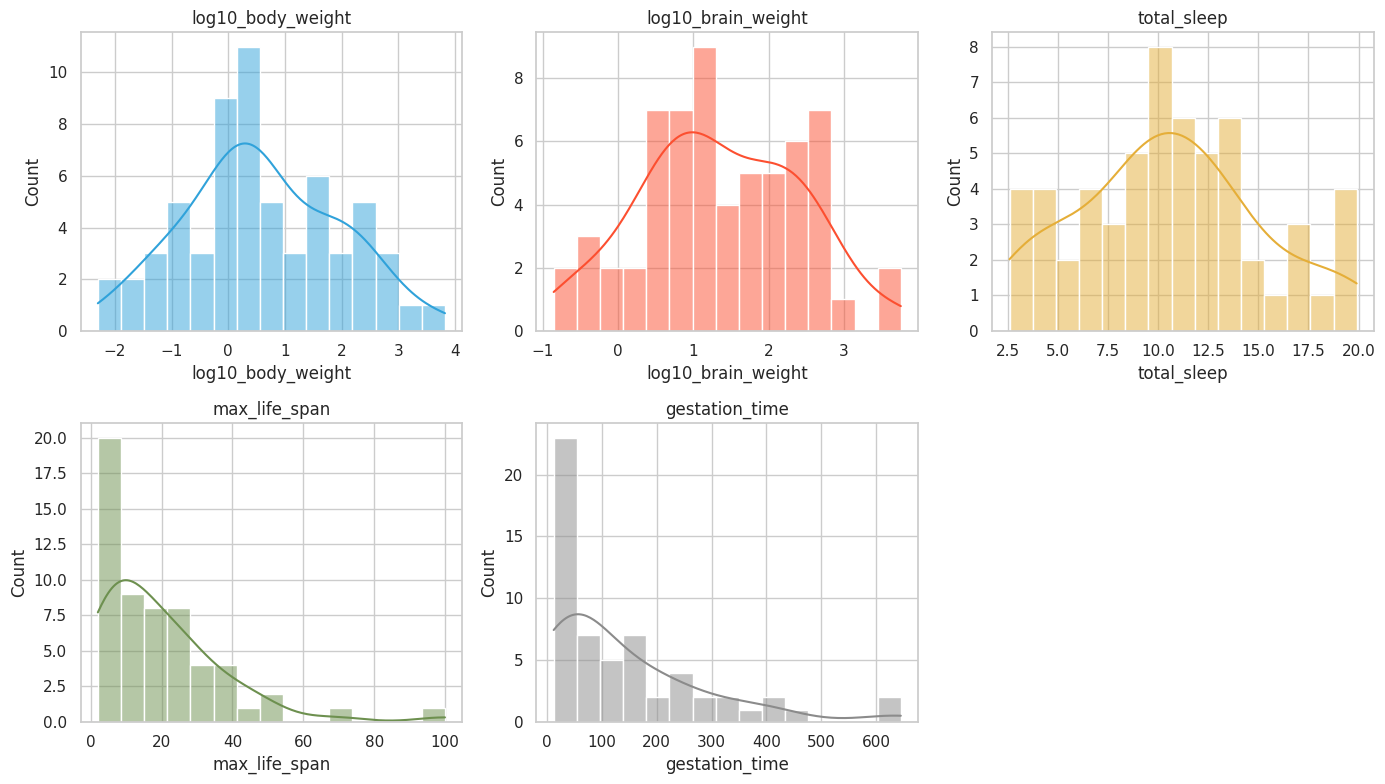

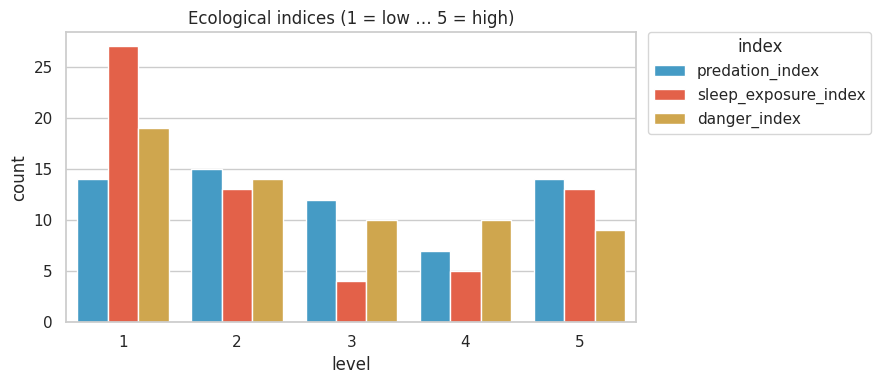

total_sleep summary (hours/day):
count    58.00
mean     10.53
std       4.61
min       2.60
25%       8.05
50%      10.45
75%      13.20
max      19.90


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, col, color in [
    (axes[0], "log10_body_weight", "#30a2da"),
    (axes[1], "log10_brain_weight", "#fc4f30"),
    (axes[2], "total_sleep", "#e5ae38"),
    (axes[3], "max_life_span", "#6d904f"),
    (axes[4], "gestation_time", "#8b8b8b"),
]:
    sns.histplot(df[col].dropna(), bins=15, kde=True, ax=ax, color=color)
    ax.set_title(col)
axes[5].axis("off")
plt.tight_layout()
plt.show()

melt_idx = df[INDEX_COLS].melt(var_name="index", value_name="level")
fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=melt_idx, x="level", hue="index", ax=ax)
ax.set_title("Ecological indices (1 = low … 5 = high)")
ax.legend(title="index", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

print("total_sleep summary (hours/day):")
print(df["total_sleep"].describe().round(2).to_string())

**Interpretation** <br>
On log scales the two weight columns become well-behaved and roughly symmetric — the transform is doing real work. `total_sleep` is broad and centered near 10–11 hours/day. Lifespan and gestation stay right-skewed even in raw form (a few elephants/primates stretch the tail). The ecological ordinals lean toward the low-danger end: most sampled species are level 1–2 on predation and danger, so the high-danger boxes later rest on few animals — another reason to prefer rank correlations over means.

# **4. Brain–Body Allometry:** <a id="Allometry"></a>

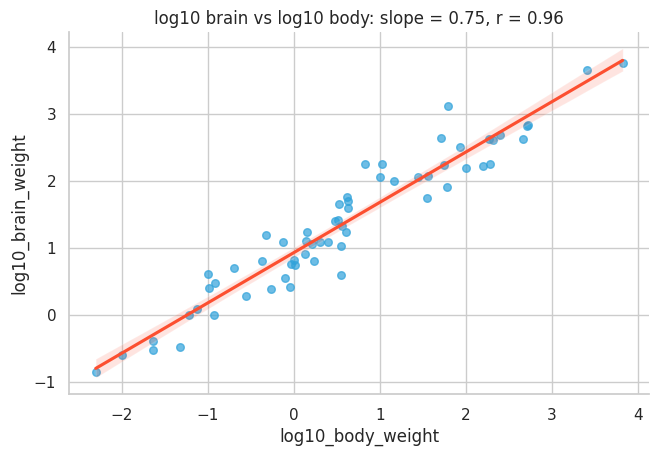

Allometric exponent (log-log slope): 0.752 ± 0.028
Pearson r (log-log): 0.960, p = 9.84e-35


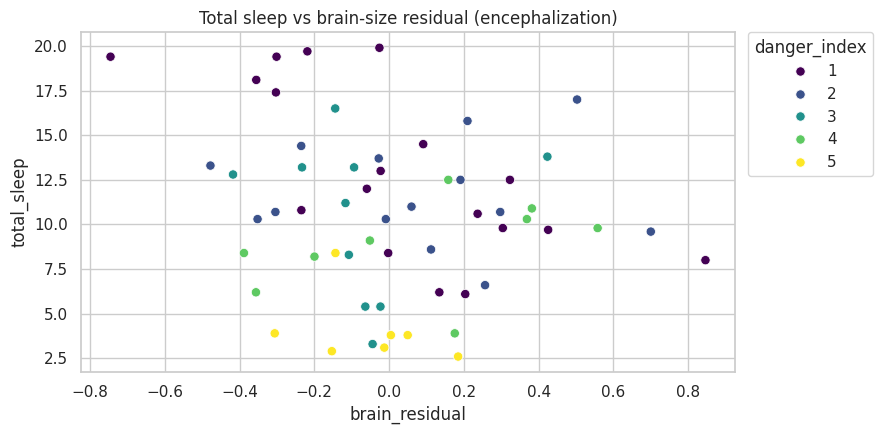

r(brain_residual, total_sleep) = -0.199 (n = 58)


In [5]:
slope, intercept, r_value, p_value, stderr = stats.linregress(df["log10_body_weight"], df["log10_brain_weight"])
g = sns.lmplot(
    data=df, x="log10_body_weight", y="log10_brain_weight", height=4.5, aspect=1.5,
    scatter_kws={"alpha": 0.7, "s": 30, "color": "#30a2da"}, line_kws={"color": "#fc4f30"},
)
g.ax.set_title(f"log10 brain vs log10 body: slope = {slope:.2f}, r = {r_value:.2f}")
plt.show()
print(f"Allometric exponent (log-log slope): {slope:.3f} ± {stderr:.3f}")
print(f"Pearson r (log-log): {r_value:.3f}, p = {p_value:.2e}")

# Encephalization residual: brain size relative to the allometric expectation for that body size
df["brain_residual"] = df["log10_brain_weight"] - (intercept + slope * df["log10_body_weight"])
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.scatterplot(data=df, x="brain_residual", y="total_sleep", hue="danger_index", palette="viridis", s=45, ax=ax)
ax.set_title("Total sleep vs brain-size residual (encephalization)")
ax.legend(title="danger_index", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()
sub = df.dropna(subset=["total_sleep"])
r_resid = float(sub["brain_residual"].corr(sub["total_sleep"]))
print(f"r(brain_residual, total_sleep) = {r_resid:.3f} (n = {len(sub)})")

**Interpretation** <br>
The log-log brain–body fit is one of biology's tightest empirical laws and it holds here: r ≈ 0.96 with a slope near **0.75**, the classic three-quarter-power allometric exponent — brains grow sublinearly with bodies. The residual from that line is a size-free "brainier than expected" score (encephalization). Its relationship with sleep is much weaker than raw size's, suggesting most of the sleep–brain correlation seen later is really the body-size axis in disguise; the color gradient hints danger, not braininess, does the remaining work.

# **5. Sleep × Ecological Danger:** <a id="Danger"></a>

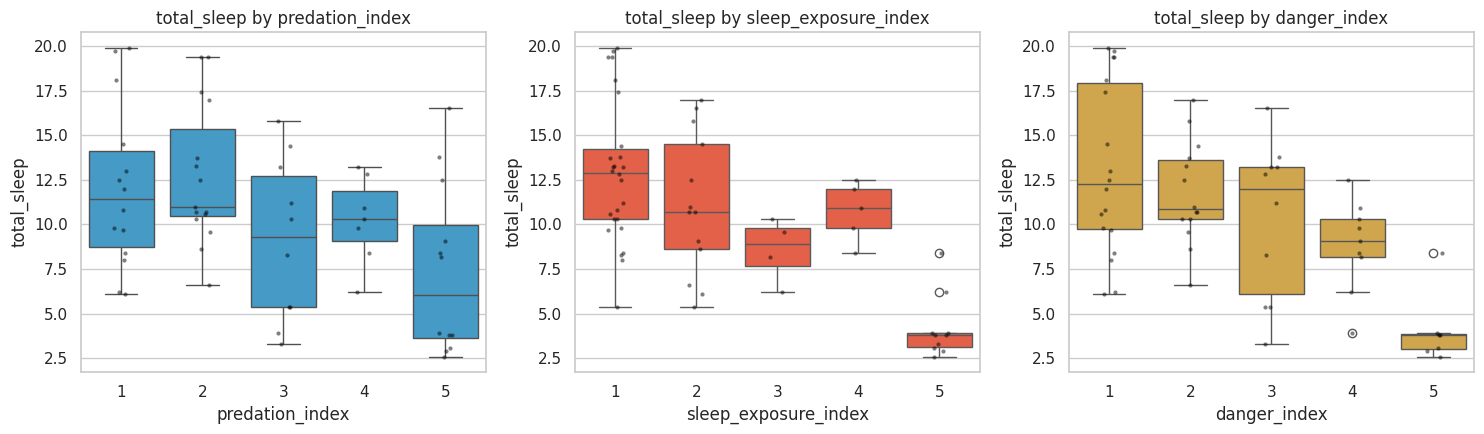

,index,spearman_rho,p_value,n
0,predation_index,-0.355,6.225877e-03,58
1,sleep_exposure_index,-0.606,4.595633e-07,58
2,danger_index,-0.524,2.420276e-05,58


total_sleep by danger_index:
              count   mean  median
danger_index                      
1                18  13.08   12.25
2                14  11.75   10.85
3                10  10.31   12.00
4                 9   8.81    9.10
5                 7   4.07    3.80


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, color in zip(axes, INDEX_COLS, ["#30a2da", "#fc4f30", "#e5ae38"]):
    sns.boxplot(data=df, x=col, y="total_sleep", ax=ax, color=color)
    sns.stripplot(data=df, x=col, y="total_sleep", ax=ax, color="black", alpha=0.5, size=3)
    ax.set_title(f"total_sleep by {col}")
plt.tight_layout()
plt.show()

sub = df.dropna(subset=["total_sleep"])
rows = []
for c in INDEX_COLS:
    rho, p = stats.spearmanr(sub[c], sub["total_sleep"])
    rows.append({"index": c, "spearman_rho": round(float(rho), 3), "p_value": float(p), "n": len(sub)})
display(pd.DataFrame(rows))

print("total_sleep by danger_index:")
print(df.groupby("danger_index")["total_sleep"].agg(["count", "mean", "median"]).round(2).to_string())

**Interpretation** <br>
The trade-off is monotone and strong: safe species (danger 1) sleep roughly 12–13 hours/day while the most endangered (danger 5) manage around 4. All three ordinals correlate negatively with sleep, led by `sleep_exposure_index` (Spearman ρ ≈ −0.61) — *where* an animal sleeps matters even more than how hunted it is — with the composite `danger_index` next (ρ ≈ −0.52) and raw `predation_index` weakest (ρ ≈ −0.36). The strip points matter here — the high-danger levels hold only 7–10 species each, so the medians are honest but fragile. Ecologically the story reads cleanly: long sleep is a luxury of animals with somewhere safe to do it.

# **6. Correlations:** <a id="Correlations"></a>

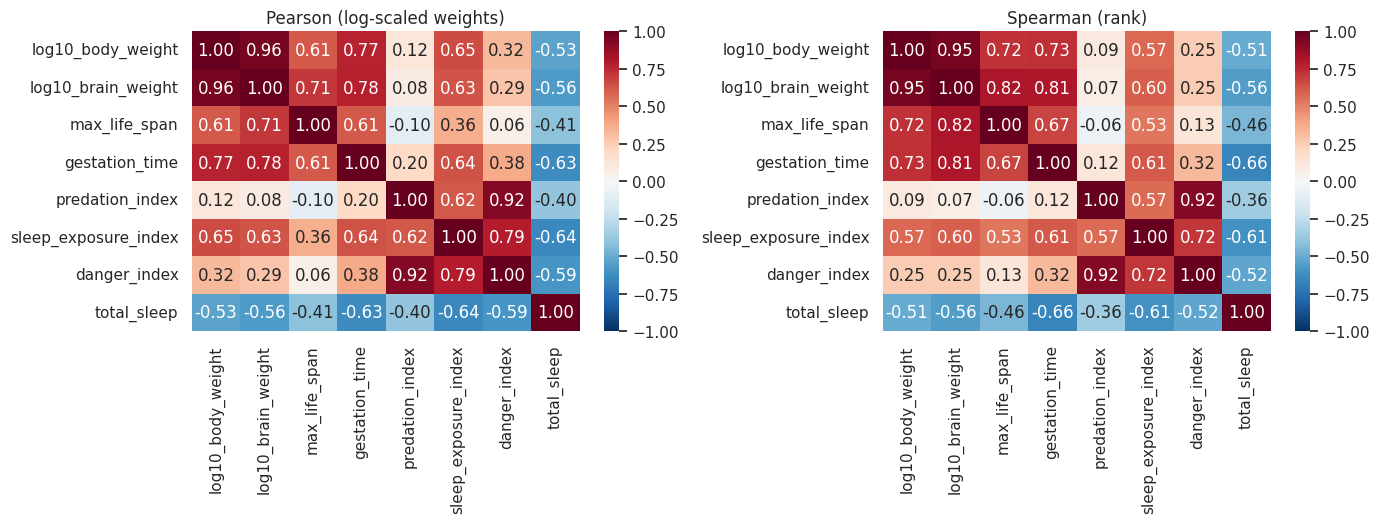

Spearman rho with total_sleep:
gestation_time         -0.657
sleep_exposure_index   -0.606
log10_brain_weight     -0.557
danger_index           -0.524
log10_body_weight      -0.506
max_life_span          -0.457
predation_index        -0.355


In [7]:
CORR_COLS = [
    "log10_body_weight", "log10_brain_weight", "max_life_span", "gestation_time",
    "predation_index", "sleep_exposure_index", "danger_index", "total_sleep",
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
sns.heatmap(df[CORR_COLS].corr(method="pearson"), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson (log-scaled weights)")
sns.heatmap(df[CORR_COLS].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman (rank)")
plt.tight_layout()
plt.show()

sleep_corr = df[CORR_COLS].corr(method="spearman")["total_sleep"].drop("total_sleep").sort_values()
print("Spearman rho with total_sleep:")
print(sleep_corr.round(3).to_string())

**Interpretation** <br>
Two correlated blocks emerge. A **life-history block** — body size, brain size, lifespan, gestation — where everything moves together (big animals live long and gestate long), and a **risk block** of the three ecological ordinals. `total_sleep` is negative against *both* blocks: bigger/slower-living and more endangered species both sleep less. The blocks are themselves entangled (big grazers tend to be exposed sleepers), which is exactly the collinearity the small regression next has to respect — one representative per block, not all eight variables at once.

# **7. Linear Regression on Total Sleep:** <a id="Regression"></a>

Model n = 54 of 62 species
In-sample R^2 = 0.613 (directional only — no held-out split at this sample size)


,std_coef
danger_index,-2.056
gestation_time,-1.378
log10_body_weight,-1.137


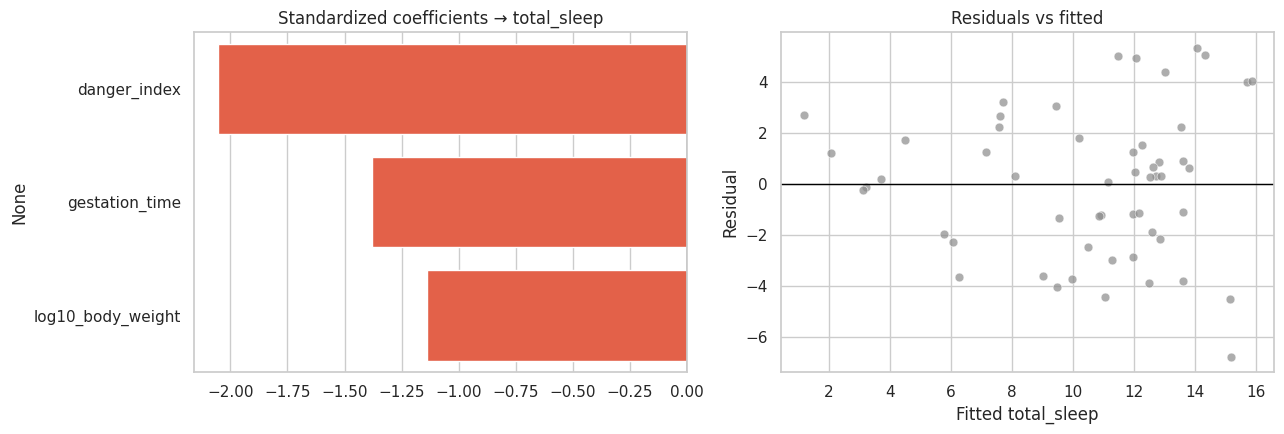

In [8]:
# One representative per correlated block: size (log body), life-history pace (gestation), risk (danger)
# Brain weight and lifespan are omitted as near-duplicates of body size / gestation at n≈50
FEATURES = ["log10_body_weight", "gestation_time", "danger_index"]
model_df = df.dropna(subset=FEATURES + ["total_sleep"]).copy()
print("Model n =", len(model_df), "of", len(df), "species")

X = StandardScaler().fit_transform(model_df[FEATURES])
y = model_df["total_sleep"].to_numpy()
lr = LinearRegression().fit(X, y)
pred = lr.predict(X)
r2 = r2_score(y, pred)

coef = pd.Series(lr.coef_, index=FEATURES).sort_values(key=np.abs, ascending=False)
print(f"In-sample R^2 = {r2:.3f} (directional only — no held-out split at this sample size)")
display(coef.rename("std_coef").to_frame().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=coef.values, y=coef.index, ax=axes[0],
            palette=["#30a2da" if v >= 0 else "#fc4f30" for v in coef.values])
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Standardized coefficients → total_sleep")
sns.scatterplot(x=pred, y=y - pred, s=40, alpha=0.7, ax=axes[1], color="#8b8b8b")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Residuals vs fitted")
axes[1].set_xlabel("Fitted total_sleep")
axes[1].set_ylabel("Residual")
plt.tight_layout()
plt.show()

**Interpretation** <br>
With one representative per block, over 60% of the sleep variance is explained (R² ≈ 0.61) and **all three coefficients are negative** — size, life-history pace, and danger each subtract sleep after controlling for the other two. Danger carries the largest standardized weight (≈ −2.1 hours per SD), ahead of gestation and body size, so the ecological effect is not just "big animals are exposed." Residuals are reasonably centered; at n = 54 this is a descriptive decomposition, not a causal claim, and swapping block representatives (brain for body, lifespan for gestation) is the natural robustness drill.

# **8. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
The classic 62-species mammal sleep table (Allison & Cicchetti, 1976): body/brain size, life-history variables, three 1–5 ecological risk ordinals, and total daily sleep — with `"?"` placeholders parsed into honest NaNs.

**Working takeaways:** <br>
- Log10 transforms are mandatory: body mass spans a 5-gram bat to a 6.6-tonne elephant.
- Brain–body allometry reproduces the textbook result: log-log slope ≈ 0.75, r ≈ 0.96.
- Sleep declines monotonically with ecological risk (safe species ~12–13 h/day, most endangered ~4 h/day); sleeping-site exposure is the strongest ordinal (ρ ≈ −0.61), ahead of the composite danger index (ρ ≈ −0.52).
- Correlations split into a life-history block and a risk block, both negatively tied to sleep and entangled with each other; gestation time is the single strongest sleep associate (ρ ≈ −0.66).
- A three-feature standardized OLS (log body, gestation, danger) explains ~61% of sleep variance with all-negative coefficients, danger weighted heaviest.
- Encephalization (brain residual) adds little beyond raw size — sleep tracks the size axis, not "braininess".

**Open follow-ups:** <br>
- Split total sleep into slow-wave vs paradoxical (REM) sleep — the original study found danger hits REM hardest (not in this export).
- Robustness: swap block representatives (brain for body, lifespan for gestation) and compare coefficients.
- Phylogenetic caution: rows are species, not independent draws — related species share ancestry; a phylogenetically-controlled model would shrink effects.
- Quantile view: is the sleep–danger effect stronger at the long-sleep end of the distribution?